In [1]:
import tensorflow as tf
import tensorflow.keras.optimizers
import tensorflow.keras.metrics
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt
import numpy as np
import pickle
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cf
import pickle 
from datetime import date, datetime, timedelta
import xarray as xr
import netCDF4 as nc
#from u_interpolate_small import regrid_irregular_quick
#import u_interpolate_small as uint
from ndays import numOfDays
import glob
import calendar
import os
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import math


2025-03-09 00:05:39.108409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741478739.118719 1057959 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741478739.121863 1057959 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-09 00:05:39.132884: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/jawahm/miniforge3/lib/python3.10/site-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A 

In [2]:
# Define domain and time period
start_lat = -8 #7.5 
end_lat = 7 #7.5 
start_lon = 26.5 
end_lon = 47 
start_year = '2005'
start_month = '03'
end_year = '2019'
end_month = '03'
start_day = '01'
end_day = '31'



In [3]:
# get native MSG grid (core)
coords_filename = glob.glob('/prj/Africa_cloud/geoloc/*.npz')[0]  # this is /prj/Africa_cloud/geoloc/*.npz on the Linux system
msg_latlon = np.load(coords_filename)
mlon = msg_latlon['lon']
mlat = msg_latlon['lat']

# find core indices using one file
lat_ind = np.where((mlat[:,100]>=start_lat) & (mlat[:,100]<=end_lat))[0]
lon_ind = np.where((mlon[1000,:]>=start_lon) & (mlon[1000,:]<=end_lon))[0]
lat = mlat[lat_ind[0]:lat_ind[-1]+1,lon_ind[0]:lon_ind[-1]+1]
lon = mlon[lat_ind[0]:lat_ind[-1]+1,lon_ind[0]:lon_ind[-1]+1]



In [4]:
# read in cores data
list_of_file_names = []

for m in range(int(start_month),int(end_month)+1,1): # 1 to include the end month
    if m<10:
        month = str(m).zfill(2)
    else:
        month = str(m)  
        #dir_name = '/prj/nflics/hist_cores/'+start_year+'/'+month+'/'+day+'/'
    dir_name = '/prj/Africa_cloud/ch9_wavelet/'+start_year+'/'+month+'/' 
    all_file_names=sorted(glob.glob(dir_name+"*.nc"));  #Hist_cores_wa_
    list_of_file_names.append(all_file_names) # all days in month
                  
list_of_files=[]                
for a in range(0,len(list_of_file_names),1):
    list_of_files = list_of_files+list_of_file_names[a]

#print(len(list_of_files))

In [5]:
total_files=len(list_of_files)
cores = np.zeros((total_files,len(lat[:,1]),len(lon[1,:])),dtype=float)
tir = np.zeros((total_files,len(lat[:,1]),len(lon[1,:])),dtype=float)
time_core = np.zeros((total_files)) 


In [6]:
print(len(list_of_files))

2962


In [7]:
for l in range(0,len(list_of_files),1):#, 
    core_filename = list_of_files[l]
    print(core_filename)
    ds = xr.open_dataset(core_filename).squeeze() 
    print(l)
    core_temp = ds['cores'].values
    cores[l,:,:] = core_temp[lat_ind[0]:lat_ind[-1]+1,lon_ind[0]:lon_ind[-1]+1]
    #uint.interpolate_data(ds['cores'].values, inds, weights, shape) # interpolation using saved weights for MSG cores       
    tir_temp =  ds['tir'].values  #/10000
    tir[l,:,:] = tir_temp[lat_ind[0]:lat_ind[-1]+1,lon_ind[0]:lon_ind[-1]+1]    
    time_core[l] = int(core_filename[-15:-3])
 

/prj/Africa_cloud/ch9_wavelet/2005/03/200503010000.nc
0
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010015.nc
1
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010030.nc
2
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010045.nc
3
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010100.nc
4
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010115.nc
5
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010130.nc
6
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010145.nc
7
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010200.nc
8
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010215.nc
9
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010230.nc
10
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010245.nc
11
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010300.nc
12
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010315.nc
13
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010330.nc
14
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010345.nc
15
/prj/Africa_cloud/ch9_wavelet/2005/03/200503010400.nc
16
/prj/Africa_cloud/ch9_wavelet/2005/03/200

In [4]:
## a clean way of plotting - use matplotlib functions directly:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
def draw_map(ax, data, lon, lat, title=None,  mask_sig=None, quiver=None, contour=None, cbar_label=None, **kwargs):

    mapp = ax.contourf(lon, lat, data, transform=ccrs.PlateCarree(), **kwargs)  # this is the actual plot
    
    ## mask for significance indicator
    if mask_sig is not None:
         plt.contourf(lon, lat, mask_sig, colors='none', hatches='.',
                     levels=[0.5, 1], linewidth=0.1)
    
    ## quiver list
    if quiver is not None:
        qu = ax.quiver(quiver['x'], quiver['y'], quiver['u'], quiver['v'], scale=quiver['scale'])
    ## additional contour on plot   
    if contour is not None:
        ax.contour(contour['x'], contour['y'], contour['data'], levels=contour['levels'], cmap=contour['cmap'] )
          
    ax.coastlines()   ## adds coastlines
    # Gridlines
    xl = ax.gridlines(draw_labels=True);   # adds latlon grid lines
    xl.top_labels = False   ## labels off
    xl.right_labels = False
    plt.title(title)
    # Countries
    ax.add_feature(cartopy.feature.BORDERS, linestyle='--'); # adds country borders
    cbar = plt.colorbar(mapp)  # adds colorbar
    cbar.set_label(cbar_label)

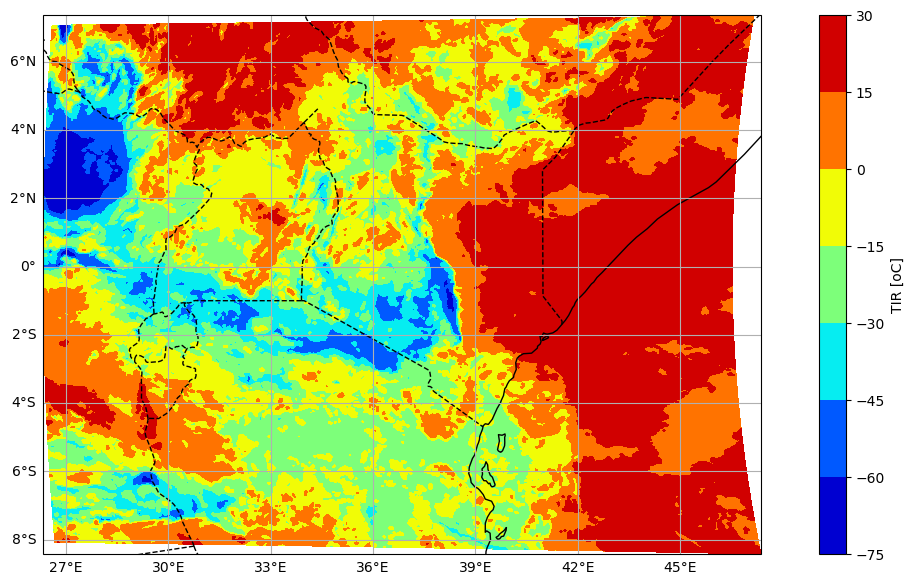

In [9]:
day = 1
f=plt.figure(figsize=(15,7))  # this opens a plot window
ax = f.add_subplot(111, projection=ccrs.PlateCarree())  # this opens a new plot axis
draw_map(ax, tir[day,:,:], lon, lat,  cbar_label='TIR [oC]', cmap='jet')
#draw_map(ax, tir_temp, mlon, mlat,  cbar_label='TIR [oC]', cmap='jet')
ax.contour(lon, lat, cores[day,:,:], colors='r')


In [24]:
# pre-process inputs
num_frames= 3   # 
t0= 1  #1   
a= -33
b= 19
lead_time= 1

ind = np.where(cores>0)
cores[ind] = 1
cores_t_0 = cores[0:(-num_frames-t0)*lead_time,:a,b:]
tir_t_0 = tir[0:(-num_frames-t0)*lead_time,:a,b:]
ind_tir = np.where(tir_t_0>-0.01)
tir_t_0[ind_tir] = 0
tir_t_0[np.isnan(tir_t_0)] = 0
tir_t_0 = np.round(tir_t_0/-173,4)

#target data
cores_t_plus_xhr = cores[(t0+num_frames)*lead_time:,:a,b:]
prediction_time = time_core[(t0+num_frames)*lead_time:]

tir_t_0_minus_2 = tir_t_0[0:-4*2]
tir_t_0_minus_1 = tir_t_0[4*1:-4*1]
tir_t_0 = tir_t_0[4*2:]
cores_t_plus_xhr= cores_t_plus_xhr[4*2:]
to_minus2_time = prediction_time[0:-4*2]
prediction_time = prediction_time[4*2:]



In [25]:
# Define input shape
#num_frames= 24  # 6 hours
image_height= len(cores_t_plus_xhr[1,:,1]) #lat
image_width= len(cores_t_plus_xhr[1,1,:]) #lon
num_channels= 3 #  core at t0-, core at t0-1,  


total_samples= int(tir_t_0.shape[0])
x_train= np.zeros((total_samples,image_height,image_width, num_channels))
x_train[:,:,:,0]= tir_t_0_minus_2
x_train[:,:,:,1]= tir_t_0_minus_1
x_train[:,:,:,2]= tir_t_0
y_train= cores_t_plus_xhr


sample_keep=[]
for sample in range(0,total_samples,1):
    # check time between files 
    to_2_datetime=datetime.strptime(str(int(to_minus2_time[sample])), '%Y%m%d%H%M')
    to_datetime=datetime.strptime(str(int(prediction_time[sample])), '%Y%m%d%H%M')
    time_difference = to_datetime-to_2_datetime    
    if time_difference< timedelta(hours=4.1):
        sample_keep.append(sample)
        
print(len(sample_keep))
  
x_train=x_train[sample_keep]
y_train=y_train[sample_keep]
prediction_time= prediction_time[sample_keep]

x_tr, x_test, y_tr, y_test, time_tr, time_test = train_test_split(x_train,y_train,prediction_time, test_size=0.2,random_state=42)
del x_train

2950


In [26]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, concatenate, Conv2D, MaxPooling2D, Activation, UpSampling2D)
from tensorflow.keras import layers


# Define input shape
image_height= 512 #len(cores_t_plus_xhr[1,:,1]) #
image_width= 512 #len(cores_t_plus_xhr[1,1,:]) #
num_channels= 3 #   
#meta_input_shape= 32x32x8

# define conv layer
def conv_layer(x_in, filters, gn_num, strides = 1, shape = (image_height,image_width), name=None):
    x = Conv2D(filters, 5, strides=strides, padding='same')(x_in)
    x = Activation('relu', name = name)(x)
   ## x = layers.BatchNormalization()(x)
    #x = tfa.layers.GroupNormalization(groups=gn_num, axis=3)(x) # could replace this with BatchNorm
    return x

# def basic unet structure
def unet_basic(input_shape=(image_height, image_width, num_channels), meta_input_shape=(image_height, image_width,1) ,chan_num=num_channels):

    inputs = Input(shape=input_shape)    # 256 x 256 x 2
    meta_inputs = Input(shape=meta_input_shape)

    # downsample
    down2 = conv_layer(inputs, 4, 1)     # 256 x 256 x 4
    down2_pool = MaxPooling2D((2, 2), strides=None)(down2)   # 128 x 128 x 4

    down3 = conv_layer(down2_pool, 8, None) # 128 x 128 x 8
    down3_pool = MaxPooling2D((4, 4), strides=None)(down3) # 32 x 32 x 8
    #print(down3_pool.shape)
 
    center = conv_layer(down3_pool, 16, None) # 32 x 32 x 16
    center = conv_layer(center, 8, None) # 32 x 32 x 8
  
    up3 = UpSampling2D((4, 4))(center) # 128 x 128 x 8
    up3 = concatenate([down3, up3], axis=3) # 128 x 128 x 16
    up3 = conv_layer(up3, 4, None) # 128 x 128 x 4

    up2 = UpSampling2D((2, 2))(up3) # 256 x 256 x 4
    up2 = concatenate([down2, up2, meta_inputs], axis=3) # 256 x 256 x 9
#    up2 = concatenate([down2, up2], axis=3) # 256 x 256 x 8
    up2 = conv_layer(up2, 4, None) # 256 x 256 x 4
  
    # predict
    output = Conv2D(1, (1, 1))(up2)
#    time_conv = layers.concatenate([output, meta_inputs]) # 256x256x2
    #time_conv = layers.concatenate([up2, meta_inputs]) # 256x256x2
  #  output1 = conv_layer(time_conv, 1, None) # 256 x 256 x 1
#    output2 = layers.Activation('sigmoid', dtype='float32', name='prob_pred')(output1)
    output1 = layers.Activation('sigmoid', dtype='float32', name='prob_pred')(output)
    
    # create model object
    unet = Model(inputs=[inputs,meta_inputs], outputs=output1, name = 'prob_map_unet')
    return unet


unet_model = unet_basic(input_shape=(image_height, image_width, num_channels),meta_input_shape=(image_height, image_width,1), chan_num=num_channels)


In [5]:
def _create_mean_filter(half_num_rows, half_num_columns, num_channels):
    """Creates convolutional filter that computes mean.

    M = number of rows in filter
    N = number of columns in filter
    C = number of channels

    :param half_num_rows: Number of rows on either side of center.  This is
        (M - 1) / 2.
    :param half_num_columns: Number of columns on either side of center.  This
        is (N - 1) / 2.
    :param num_channels: Number of channels.
    :return: weight_matrix: M-by-N-by-C-by-C numpy array of filter weights.
    """

    num_rows = 2 * half_num_rows + 1
    num_columns = 2 * half_num_columns + 1
    weight = 1. / (num_rows * num_columns)

    return np.full(
        (num_rows, num_columns, num_channels, num_channels), weight,
        dtype=np.float32
    )

def FSS_loss(target_tensor, prediction_tensor):
    
    half_window_size_px=2
    use_as_loss_function=True 
    #mask_matrix
    function_name=None
    test_mode=False
    """Fractions skill score (FSS).

    M = number of rows in grid
    N = number of columns in grid

    :param half_window_size_px: Number of pixels (grid cells) in half of
        smoothing window (on either side of center).  If this argument is K, the
        window size will be (1 + 2 * K) by (1 + 2 * K).
    :param use_as_loss_function: Boolean flag.  FSS is positively oriented
        (higher is better), but if using it as loss function, we want it to be
        negatively oriented.  Thus, if `use_as_loss_function == True`, will
        return 1 - FSS.  If `use_as_loss_function == False`, will return just
        FSS.
    :param mask_matrix: M-by-N numpy array of Boolean flags.  Grid cells marked
        "False" are masked out and not used to compute the loss.
    :param function_name: Function name (string).
    :param test_mode: Leave this alone.
    :return: loss: Loss function (defined below).
    """

    weight_matrix = _create_mean_filter(
        half_num_rows=half_window_size_px,
        half_num_columns=half_window_size_px, num_channels=1
    )
       
    #print(target_tensor.shape)
    #print(prediction_tensor.shape)
    #print(weight_matrix.shape)
        
    """Computes loss (fractions skill score).

        :param target_tensor: Tensor of target (actual) values.
        :param prediction_tensor: Tensor of predicted values.
        :return: loss: Fractions skill score.
    """

    smoothed_target_tensor = K.conv2d(
        x=target_tensor, kernel=weight_matrix,
        padding='same', strides=(1, 1), data_format='channels_last'
    )

    smoothed_prediction_tensor = K.conv2d(
        x=prediction_tensor, kernel=weight_matrix,
        padding='same', strides=(1, 1), data_format='channels_last'
    )

    #smoothed_target_tensor = smoothed_target_tensor * eroded_mask_matrix
    #smoothed_prediction_tensor = smoothed_prediction_tensor * eroded_mask_matrix)

    actual_mse = K.mean(
        (smoothed_target_tensor - smoothed_prediction_tensor) ** 2
    )
    reference_mse = K.mean(
        smoothed_target_tensor ** 2 + smoothed_prediction_tensor ** 2
    )

    if use_as_loss_function:
        return actual_mse / reference_mse

    return 1. - actual_mse / reference_mse

    if function_name is not None:
        loss.__name__ = function_name


In [28]:
unet_model.compile(optimizer=tensorflow.keras.optimizers.Adam(),
                  loss=FSS_loss,
                  metrics=[tf.keras.metrics.Accuracy()])
#                  metrics=metric_list)

In [29]:
time_of_day_tr= np.zeros((time_tr.shape[0],image_height, image_width,1))

for i in range(0,len(time_tr)):
    print(time_tr[i])
#    time_of_day = "{0:.2g}".format(float(str(time_tr[i])[-6:])/2345)
    time_of_day = float(str(time_tr[i])[-6:])/2345
    time_of_day_tr[i,:,:,:]=round(np.sin(time_of_day*math.pi),2)
    print(time_of_day_tr[i,0,0,0])
    #break
               

200503251330.0
0.98
200503212100.0
0.32
200503032000.0
0.45
200503131600.0
0.84
200503251745.0
0.72
200503280645.0
0.76
200503150100.0
0.13
200503252130.0
0.28
200503310945.0
0.95
200503291215.0
1.0
200503161915.0
0.54
200503290130.0
0.17
200503250045.0
0.06
200503052115.0
0.3
200503052245.0
0.13
200503232345.0
0.0
200503071945.0
0.51
200503050230.0
0.3
200503260545.0
0.67
200503071215.0
1.0
200503310630.0
0.75
200503220415.0
0.53
200503241600.0
0.84
200503311515.0
0.9
200503180115.0
0.15
200503090800.0
0.88
200503121530.0
0.89
200503250930.0
0.95
200503241515.0
0.9
200503211245.0
1.0
200503061845.0
0.62
200503201845.0
0.62
200503121915.0
0.54
200503182100.0
0.32
200503120015.0
0.02
200503260030.0
0.04
200503200045.0
0.06
200503151330.0
0.98
200503102015.0
0.43
200503302130.0
0.28
200503110345.0
0.45
200503101130.0
1.0
200503172330.0
0.02
200503220115.0
0.15
200503051600.0
0.84
200503082045.0
0.39
200503031430.0
0.94
200503162200.0
0.19
200503020630.0
0.75
200503231330.0
0.98
200503022

In [6]:
from tensorflow.python.keras.engine import data_adapter

def _is_distributed_dataset(ds):
    return isinstance(ds, data_adapter.input_lib.DistributedDatasetSpec)

data_adapter._is_distributed_dataset = _is_distributed_dataset

tf.config.run_functions_eagerly(True)

In [31]:
epochs =  20
batch_size = 4 #50# batch_size#24
y_tr=tf.expand_dims(y_tr, axis=3)

# Fit the model to the training data.
model_history = unet_model.fit([x_tr,time_of_day_tr],
                               y_tr,
                               batch_size=batch_size,
                               epochs=epochs,
                               validation_split = 0.3)
#    callbacks=[early_stopping, reduce_lr],


/home/jawahm/miniforge3/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/20


I0000 00:00:1741477157.754537 1053960 cuda_dnn.cc:529] Loaded cuDNN version 90300


413/413 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 2.0547e-04 - loss: 0.7563 - val_accuracy: 0.0000e+00 - val_loss: 0.5335
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.0000e+00 - loss: 0.4353 - val_accuracy: 0.0000e+00 - val_loss: 0.4141
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.0000e+00 - loss: 0.4103 - val_accuracy: 0.0000e+00 - val_loss: 0.3680
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.0000e+00 - loss: 0.3537 - val_accuracy: 0.0000e+00 - val_loss: 0.4036
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.0000e+00 - loss: 0.3572 - val_accuracy: 0.0000e+00 - val_loss: 0.3482
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.0000e+00 - loss: 0.3418 - val_accuracy: 0.0000e+00 - val_loss: 0.3428
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 1.9503e-06 - loss: 0.3319 - val_accuracy: 5.2802e-07 - val_loss: 0.3602
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 25s 6

In [7]:
modelFile= '../../pkl_files/kenya/512_models/1hr_using_1hr/KY_M_trained_model_'+start_year+'.h5'
#unet_model.save(modelFile)
unet_model = tf.keras.models.load_model(modelFile, compile=False,custom_objects={'loss': FSS_loss})


unet_model.compile(optimizer=tensorflow.keras.optimizers.Adam(),
                  loss=FSS_loss,
                  metrics=[tf.keras.metrics.Accuracy()])



I0000 00:00:1741478842.995066 1057959 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43573 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:02:00.0, compute capability: 8.6


In [33]:
del x_tr, x_test, y_tr, y_test, time_tr, time_test


In [8]:
image_height= 512 #len(cores_t_plus_xhr[1,:,1]) #
image_width= 512 #len(cores_t_plus_xhr[1,1,:]) #
num_channels= 3 #   

In [9]:
for current_year in range(int(start_year)+1,int(end_year)+1,1):
    print(current_year)
    
    # load files
    list_of_file_names = []

    for m in range(int(start_month),int(end_month)+1,1): # 1 to include the end month
        dir_name = '/prj/Africa_cloud/ch9_wavelet/'+str(current_year)+'/'+str(m).zfill(2)+'/' 
        all_file_names=sorted(glob.glob(dir_name+"*.nc"));  #Hist_cores_wa_
        list_of_file_names.append(all_file_names) # all days in month
                   
    list_of_files=[]                
    for file in range(0,len(list_of_file_names),1):
        list_of_files = list_of_files+list_of_file_names[file]
    print(list_of_files[0])

    total_files=len(list_of_files)
    cores = np.zeros((total_files,len(lat[:,1]),len(lon[1,:])),dtype=float)
    tir = np.zeros((total_files,len(lat[:,1]),len(lon[1,:])),dtype=float)
    time_core = np.zeros((total_files)) 

    # read in cores data
    for l in range(0,len(list_of_files),1): # 96 files per day
        core_filename = list_of_files[l]
        ds = xr.open_dataset(core_filename).squeeze() 
        core_temp = ds['cores'].values
        cores[l,:,:] = core_temp[lat_ind[0]:lat_ind[-1]+1,lon_ind[0]:lon_ind[-1]+1]
        tir_temp =  ds['tir'].values  #/10000
        tir[l,:,:] = tir_temp[lat_ind[0]:lat_ind[-1]+1,lon_ind[0]:lon_ind[-1]+1]    
        time_core[l] = int(core_filename[-15:-3])

    print('files read')
    
    num_frames= 3   # 
    t0= 1  #1   
    a= -33
    b= 19
    lead_time= 1

    ind = np.where(cores>0)
    cores[ind] = 1
    cores_t_0 = cores[0:(-num_frames-t0)*lead_time,:a,b:]
    tir_t_0 = tir[0:(-num_frames-t0)*lead_time,:a,b:]
    ind_tir = np.where(tir_t_0>-0.01)
    tir_t_0[ind_tir] = 0
    tir_t_0[np.isnan(tir_t_0)] = 0
    tir_t_0 = np.round(tir_t_0/-173,4)

    #target data
    cores_t_plus_xhr = cores[(t0+num_frames)*lead_time:,:a,b:]
    prediction_time = time_core[(t0+num_frames)*lead_time:]

    tir_t_0_minus_2 = tir_t_0[0:-4*2]
    tir_t_0_minus_1 = tir_t_0[4*1:-4*1]
    tir_t_0 = tir_t_0[4*2:]
    cores_t_plus_xhr= cores_t_plus_xhr[4*2:]
    to_minus2_time = prediction_time[0:-4*2]
    prediction_time=prediction_time[4*2:]

    # training samples
    total_samples= int(tir_t_0.shape[0])
    x_train= np.zeros((total_samples,image_height,image_width, num_channels))
    x_train[:,:,:,0]= tir_t_0_minus_2
    x_train[:,:,:,1]= tir_t_0_minus_1
    x_train[:,:,:,2]= tir_t_0
    y_train= cores_t_plus_xhr


    sample_keep=[]
    for sample in range(0,total_samples,1):
        # check time between files 
        to_2_datetime=datetime.strptime(str(int(to_minus2_time[sample])), '%Y%m%d%H%M')
        to_datetime=datetime.strptime(str(int(prediction_time[sample])), '%Y%m%d%H%M')
        time_difference = to_datetime-to_2_datetime    
        if time_difference< timedelta(hours=4.1):
            sample_keep.append(sample)
        
    print(len(sample_keep))
  
    x_train=x_train[sample_keep]
    y_train=y_train[sample_keep]
    prediction_time= prediction_time[sample_keep]
    
    x_tr, x_test, y_tr, y_test, time_tr, time_test = train_test_split(x_train,y_train,prediction_time, test_size=0.2,random_state=42)
    del x_train

    time_of_day_tr= np.zeros((time_tr.shape[0],image_height,image_width,1))
    for i in range(0,len(time_tr)):
        time_of_day = float(str(time_tr[i])[-6:])/2345
        time_of_day_tr[i,:,:,:]=round(np.sin(time_of_day*math.pi),2)
        
    # load old model
    epochs =  20
    batch_size = 4 #50# batch_size#24
    y_tr=tf.expand_dims(y_tr, axis=3)

    # Fit the model to the training data.
    model_history = unet_model.fit([x_tr,time_of_day_tr],
                                   y_tr,
                                   batch_size=batch_size,
                                   epochs=epochs,
                                   validation_split = 0.3)
    
    # save the model
    modelFile= '../../pkl_files/kenya/512_models/1hr_using_1hr/KY_M_trained_model_'+start_year+'_to_'+str(current_year)+'.h5'
    unet_model.save(modelFile)


    del x_tr, x_test, y_tr, y_test, time_tr, time_test
    



2006
/prj/Africa_cloud/ch9_wavelet/2006/03/200603010000.nc
files read
2958


/home/jawahm/miniforge3/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/20


I0000 00:00:1741479138.079146 1057959 cuda_dnn.cc:529] Loaded cuDNN version 90300


414/414 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 3.9236e-05 - loss: 0.3666 - val_accuracy: 1.0406e-04 - val_loss: 0.3902
Epoch 2/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 7.3544e-05 - loss: 0.3587 - val_accuracy: 4.3471e-05 - val_loss: 0.3744
Epoch 3/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 9.0837e-05 - loss: 0.3700 - val_accuracy: 7.6681e-05 - val_loss: 0.3591
Epoch 4/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 9.1153e-05 - loss: 0.3539 - val_accuracy: 6.8965e-05 - val_loss: 0.3651
Epoch 5/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 1.0034e-04 - loss: 0.3461 - val_accuracy: 5.1982e-05 - val_loss: 0.3620
Epoch 6/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 1.1239e-04 - loss: 0.3409 - val_accuracy: 1.5915e-04 - val_loss: 0.3698
Epoch 7/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 7.3256e-05 - loss: 0.3607 - val_accuracy: 3.8695e-05 - val_loss: 0.3563
Epoch 8/20
414/414 ━━━━━━━━━━━━━━━━━━━━ 26s 6

...

/home/jawahm/miniforge3/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 4.5659e-04 - loss: 0.3305 - val_accuracy: 3.3967e-04 - val_loss: 0.3044
Epoch 2/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 3.4798e-04 - loss: 0.3189 - val_accuracy: 3.4175e-04 - val_loss: 0.3112
Epoch 3/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 3.0177e-04 - loss: 0.3256 - val_accuracy: 5.6200e-04 - val_loss: 0.3015
Epoch 4/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 3.5556e-04 - loss: 0.3273 - val_accuracy: 1.0636e-04 - val_loss: 0.3103
Epoch 5/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 2.7800e-04 - loss: 0.3141 - val_accuracy: 5.1125e-04 - val_loss: 0.3210
Epoch 6/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 3.2102e-04 - loss: 0.3147 - val_accuracy: 4.0387e-04 - val_loss: 0.3002
Epoch 7/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 3.2842e-04 - loss: 0.3213 - val_accuracy: 3.6321e-04 - val_loss: 0.2987
Epoch 8/20
415/415 ━━━━━━━━━━━━━━━

2019
/prj/Africa_cloud/ch9_wavelet/2019/03/201903010000.nc
files read
2964


/home/jawahm/miniforge3/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 1.5746e-04 - loss: 0.3494 - val_accuracy: 1.7647e-04 - val_loss: 0.3333
Epoch 2/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 1.7945e-04 - loss: 0.3348 - val_accuracy: 9.8057e-05 - val_loss: 0.3447
Epoch 3/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 1.6457e-04 - loss: 0.3296 - val_accuracy: 8.0055e-05 - val_loss: 0.3364
Epoch 4/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 1.5410e-04 - loss: 0.3227 - val_accuracy: 1.7401e-04 - val_loss: 0.3171
Epoch 5/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 1.5950e-04 - loss: 0.3261 - val_accuracy: 3.9235e-04 - val_loss: 0.3323
Epoch 6/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 59ms/step - accuracy: 1.8248e-04 - loss: 0.3233 - val_accuracy: 1.2367e-04 - val_loss: 0.3128
Epoch 7/20
415/415 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 2.0586e-04 - loss: 0.3154 - val_accuracy: 3.0761e-04 - val_loss: 0.3160
Epoch 8/20
415/415 ━━━━━━━━━━━━━━━

In [8]:
modelFile= '../../pkl_files/kenya/512_models/1hr_using_1hr/KY_M_trained_model_2005_to_2019.h5'
#unet_model.save(modelFile)
#unet_model = tf.keras.models.load_model(modelFile, compile=False,custom_objects={'loss': FSS_loss})


#unet_model.compile(optimizer=tensorflow.keras.optimizers.Adam(),
 #                 loss=FSS_loss,
  #                metrics=[tf.keras.metrics.Accuracy()])


In [10]:
current_year='2020'
start_month = '04'
end_month='04'

# load files
list_of_file_names = []

for m in range(int(start_month),int(end_month)+1,1): # 1 to include the end month
    dir_name = '/prj/Africa_cloud/ch9_wavelet/'+str(current_year)+'/'+str(m).zfill(2)+'/' 
    all_file_names=sorted(glob.glob(dir_name+"*.nc"));  #Hist_cores_wa_
    list_of_file_names.append(all_file_names) # all days in month
                   
list_of_files=[]                
for file in range(0,len(list_of_file_names),1):
    list_of_files = list_of_files+list_of_file_names[file]
    # print(list_of_files)

total_files=len(list_of_files)
cores = np.zeros((total_files,len(lat[:,1]),len(lon[1,:])),dtype=float)
tir = np.zeros((total_files,len(lat[:,1]),len(lon[1,:])),dtype=float)
time_core = np.zeros((total_files)) 
    
# read in cores data
for l in range(0,len(list_of_files),1): #,  # 96 files per day
    core_filename = list_of_files[l]
    ds = xr.open_dataset(core_filename).squeeze() 
    core_temp = ds['cores'].values
    cores[l,:,:] = core_temp[lat_ind[0]:lat_ind[-1]+1,lon_ind[0]:lon_ind[-1]+1]
    tir_temp =  ds['tir'].values  #/10000
    tir[l,:,:] = tir_temp[lat_ind[0]:lat_ind[-1]+1,lon_ind[0]:lon_ind[-1]+1]    
    time_core[l] = int(core_filename[-15:-3])


# define input and ouput
ind = np.where(cores>0)
cores[ind] = 1 
cores_t_0 = cores[0:(-num_frames-t0)*lead_time,:a,b:]
tir_t_0 = tir[0:(-num_frames-t0)*lead_time,:a,b:]
ind_tir = np.where(tir_t_0>-0.01)
tir_t_0[ind_tir] = 0
tir_t_0[np.isnan(tir_t_0)] = 0
tir_t_0 = np.round(tir_t_0/-173,4)

#target data
cores_t_plus_xhr = cores[(t0+num_frames)*lead_time:,:a,b:]    
prediction_time = time_core[(t0+num_frames)*lead_time:]

tir_t_0_minus_2 = tir_t_0[0:-4*2]
tir_t_0_minus_1 = tir_t_0[4*1:-4*1]
tir_t_0 = tir_t_0[4*2:]
cores_t_plus_xhr= cores_t_plus_xhr[4*2:]
to_minus2_time = prediction_time[0:-4*2]
prediction_time=prediction_time[4*2:]
    
# Define input shape
image_height= len(cores_t_plus_xhr[1,:,1]) #lat
image_width= len(cores_t_plus_xhr[1,1,:]) #lon
num_channels= 3 #  


# training samples
total_samples= int(tir_t_0.shape[0])
x_train= np.zeros((total_samples,image_height,image_width, num_channels))
x_train[:,:,:,0]= tir_t_0_minus_2
x_train[:,:,:,1]= tir_t_0_minus_1
x_train[:,:,:,2]= tir_t_0
y_train= cores_t_plus_xhr

sample_keep=[]
for sample in range(0,total_samples,1):
    # check time between files 
    to_2_datetime=datetime.strptime(str(int(to_minus2_time[sample])), '%Y%m%d%H%M')
    to_datetime=datetime.strptime(str(int(prediction_time[sample])), '%Y%m%d%H%M')
    time_difference = to_datetime-to_2_datetime    
    if time_difference< timedelta(hours=4.1):
        sample_keep.append(sample)
print(len(sample_keep))  

x_train=x_train[sample_keep]
y_train=y_train[sample_keep]
prediction_time= prediction_time[sample_keep]
    
x_tr, x_test, y_tr, y_test, time_tr, time_test = train_test_split(x_train,y_train,prediction_time, test_size=0.8,random_state=42)
del x_train

time_of_day_test= np.zeros((time_test.shape[0],image_height,image_width,1))
for i in range(0,len(time_test)):
    time_of_day = float(str(time_test[i])[-6:])/2345
    time_of_day_test[i,:,:,:]=np.round(np.sin(time_of_day*math.pi),2)

predicted_frames= np.round(np.squeeze(unet_model.predict([x_test,time_of_day_test])),2)


#with open('./pkl_files/Predictions_1hr_using_1hr_TIR_multiyear_'+current_year+'.pkl', 'wb') as file: 
 #   pickle.dump([predicted_frames,y_test,time_test], file) 



2866


/home/jawahm/miniforge3/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step


In [11]:
predicted_frames.shape

(2293, 512, 512)

In [12]:
def FSS_accuracy_metric(target_tensor, prediction_tensor,half_window_size_px):
    
    half_window_size_px=half_window_size_px #2
    use_as_loss_function=False 
    #mask_matrix
    test_mode=False
    """Fractions skill score (FSS).

    M = number of rows in grid
    N = number of columns in grid

    :param half_window_size_px: Number of pixels (grid cells) in half of
        smoothing window (on either side of center).  If this argument is K, the
        window size will be (1 + 2 * K) by (1 + 2 * K).
    :param use_as_loss_function: Boolean flag.  FSS is positively oriented
        (higher is better), but if using it as loss function, we want it to be
        negatively oriented.  Thus, if `use_as_loss_function == True`, will
        return 1 - FSS.  If `use_as_loss_function == False`, will return just
        FSS.
    :param mask_matrix: M-by-N numpy array of Boolean flags.  Grid cells marked
        "False" are masked out and not used to compute the loss.
    :param function_name: Function name (string).
    :param test_mode: Leave this alone.
    :return: loss: Loss function (defined below).
    """

    weight_matrix = _create_mean_filter(
        half_num_rows=half_window_size_px,
        half_num_columns=half_window_size_px, num_channels=1
    )
              
    """Computes loss (fractions skill score).

        :param target_tensor: Tensor of target (actual) values.
        :param prediction_tensor: Tensor of predicted values.
        :return: loss: Fractions skill score.
    """

    smoothed_target_tensor = K.conv2d(
        x=target_tensor, kernel=weight_matrix,
        padding='same', strides=(1, 1), data_format='channels_last'
    )

    smoothed_prediction_tensor = K.conv2d(
        x=prediction_tensor, kernel=weight_matrix,
        padding='same', strides=(1, 1), data_format='channels_last'
    )

    #smoothed_target_tensor = smoothed_target_tensor * eroded_mask_matrix
    #smoothed_prediction_tensor = smoothed_prediction_tensor * eroded_mask_matrix)

    actual_mse = K.mean(
        (smoothed_target_tensor - smoothed_prediction_tensor) ** 2
    )
    reference_mse = K.mean(
        smoothed_target_tensor ** 2 + smoothed_prediction_tensor ** 2
    )

    if use_as_loss_function:
        return actual_mse / reference_mse

    return 1. - actual_mse / reference_mse



In [13]:
y_test1= tf.expand_dims(y_test, axis=3)
y_test1= tf.cast(y_test1, tf.float32)
ffs_array=[]
prob_threshold=[]

for core_prob_threshold in range(0,11,1):
    y_pred = np.zeros((x_test.shape[0],image_height,image_width))
    ind_okay = np.where(predicted_frames>core_prob_threshold/10)
    y_pred[ind_okay] = 1
    y_pred1 = tf.expand_dims(y_pred, axis=3)
    y_pred1 = tf.cast(y_pred1, tf.float32)
    FSS_Score = FSS_accuracy_metric(y_test1, y_pred1,2)
    print(FSS_Score)
    ffs_array.append(FSS_Score) 
    prob_threshold.append(core_prob_threshold/10)
    

    
#with open('../../pkl_files/WA_512_15yr/Prob_threshold_vs_Eval_FSS_scores_3channel_1hr_using_1hr_TIR_multiyear'+current_year+'.pkl', 'wb') as file: 
 #   pickle.dump([prob_threshold,ffs_array], file) 

tf.Tensor(0.22322011, shape=(), dtype=float32)
tf.Tensor(0.5657007, shape=(), dtype=float32)
tf.Tensor(0.65846753, shape=(), dtype=float32)
tf.Tensor(0.6917286, shape=(), dtype=float32)
tf.Tensor(0.69014513, shape=(), dtype=float32)
tf.Tensor(0.6753886, shape=(), dtype=float32)
tf.Tensor(0.656301, shape=(), dtype=float32)
tf.Tensor(0.63338125, shape=(), dtype=float32)
tf.Tensor(0.6046958, shape=(), dtype=float32)
tf.Tensor(0.5613754, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)


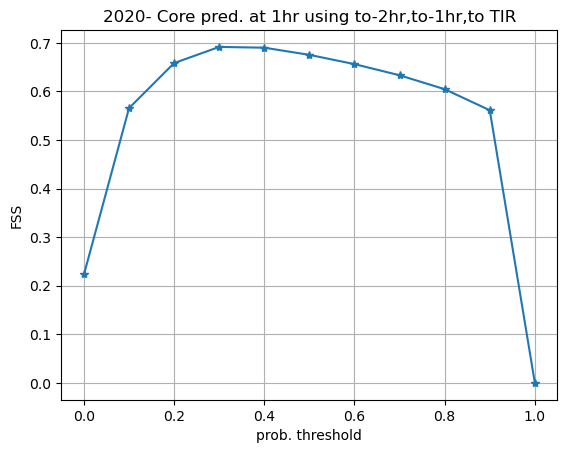

In [14]:
plt.plot(prob_threshold, ffs_array, linestyle='-',marker="*")
plt.xlabel('prob. threshold')
plt.ylabel('FSS')
# Show the plot
plt.title(current_year+'- Core pred. at 1hr using to-2hr,to-1hr,to TIR')
plt.grid()
plt.show()


In [15]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker

def plot_maps_colorbar(ax, lon, lat, data, title,levels_custom,plot_label):
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=1, color='gray', alpha=0.75, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator([20, 25, 30, 35, 40])
    gl.ylocator = mticker.FixedLocator([0, -5, -10, -15, -20, -25])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 7, 'color': 'gray'}
    gl.ylabel_style = {'size': 7, 'color': 'gray'}
    # ax.set_title(title)
    # Countries
    m=ax.contourf(lon, lat, data, transform=ccrs.PlateCarree(), levels=levels_custom,cmap='jet')  # this is the actual plot
    ax.coastlines()   ## adds coastlines
    ax.add_feature(cartopy.feature.BORDERS, linestyle='--',color='white'); # adds country borders
    cbar = plt.colorbar(m)  # adds colorbar
    cbar.set_label(plot_label)
    

In [16]:
# example date = 201008121545.0
ind = np.where(np.logical_and(time_test>= 202004271300, time_test<= 202004271600)) 
print(ind)
batch_number =  ind[0][0] # 
frames = x_test[batch_number,:,:,:] # 
original_frame = y_test[batch_number,:,:] # 
print(frames.shape)
time_of_test = time_of_day_test[batch_number, :,:,:]


# Extract the model's prediction and post-process it.
predicted_frame = unet_model.predict([np.expand_dims(frames, axis=0),np.expand_dims(time_of_test, axis=0)])


(array([ 120,  476,  553,  612,  947, 1158, 1299, 1579, 1660, 1776, 1861,
       1943]),)
(512, 512, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/home/jawahm/miniforge3/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jawahm/miniforge3/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jawahm/miniforge3/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jawahm/miniforge3/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/jawahm/miniforge3/lib/python3.10/site-packages/cartopy/mpl/feature_artist.

202004271345.0


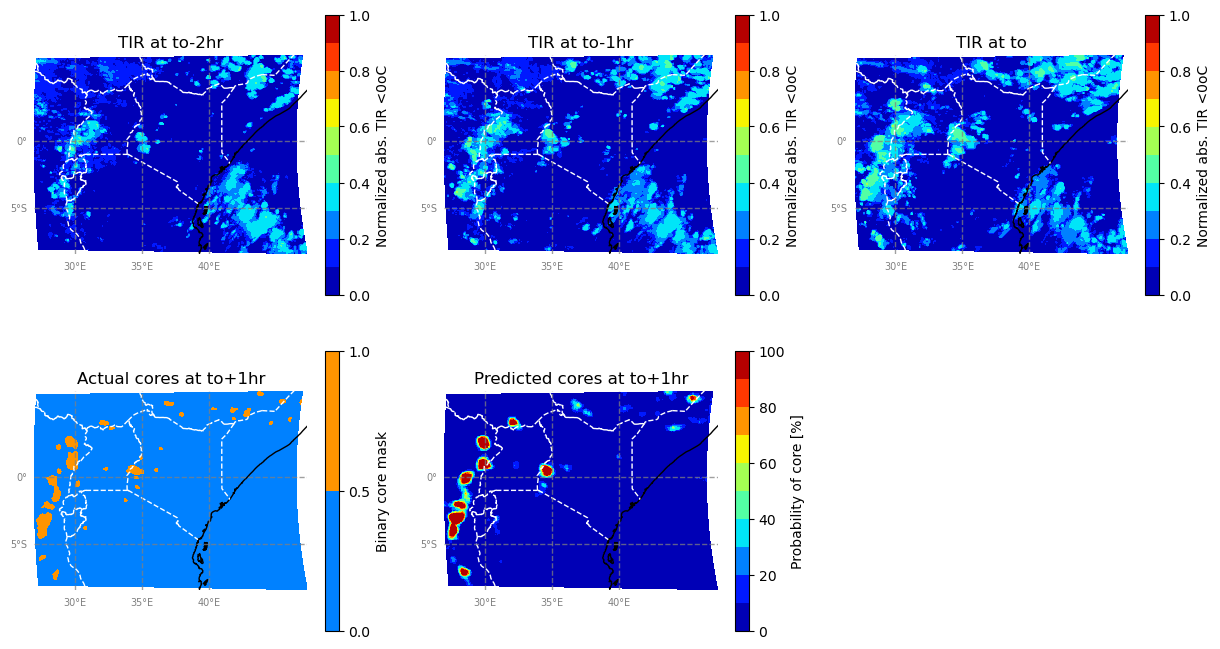

In [17]:
data = np.zeros((5,image_height,image_width))
data[0] = np.squeeze(frames[:,:,0])
data[1] = np.squeeze(frames[:,:,1])
data[2] = np.squeeze(frames[:,:,2])
data[3] = np.squeeze(original_frame[:,:])
data[4] = np.squeeze(predicted_frame[0,:,:,0]*100)
titles = ['TIR at to-2hr','TIR at to-1hr','TIR at to', 'Actual cores at to+1hr', 'Predicted cores at to+1hr']
levels_custom=[np.arange(0,1.05,.10),[0, 0.5, 1],np.arange(0,105,10)]
labels=['Normalized abs. TIR <0oC','Binary core mask','Probability of core [%]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8),subplot_kw={'projection':ccrs.PlateCarree()})
axes[1][2].set_visible(False)

for idx, ax in enumerate(axes[0]):
    plot_maps_colorbar(ax, lon[:a,b:], lat[:a,b:], data[idx],  title=None ,levels_custom= levels_custom[0],plot_label=labels[0])
    ax.set_title(titles[idx])
    ax.axis("off")

for idx, ax in enumerate(axes[1]):
    if idx==2:
        break
    if idx==0:
        plot_maps_colorbar(ax, lon[:a,b:], lat[:a,b:], data[idx+3],  title=None ,levels_custom= levels_custom[1],plot_label=labels[idx+1])
        ax.set_title(titles[idx+3])
        ax.axis("off")
    if idx==1:
        plot_maps_colorbar(ax, lon[:a,b:], lat[:a,b:], data[idx+3],  title=None ,levels_custom= levels_custom[2],plot_label=labels[idx+1])
        ax.set_title(titles[idx+3])
        ax.axis("off")    

# Print information and display the figure.
# print('Predicting core at 1hr')
print(time_test[batch_number])
plt.show()

In [18]:
y_test1= tf.expand_dims(y_test, axis=3)
y_test1= tf.cast(y_test1, tf.float32)
#[max_ffs, indx] = np.nax(ffs_array)
core_prob_threshold=0.3
y_pred = np.zeros((x_test.shape[0],image_height,image_width))
ind_okay = np.where(predicted_frames>core_prob_threshold)
y_pred[ind_okay] = 1
y_pred1 = tf.expand_dims(y_pred, axis=3)
y_pred1 = tf.cast(y_pred1, tf.float32)
half_window_size=[1, 2, 5, 7, 10, 13, 20, 30, 49]
ffs_array = []
FSS_eval_kernel=[]

for FFS_kernal_size in half_window_size:
    FSS_Score = FSS_accuracy_metric(y_test1, y_pred1,FFS_kernal_size)
    print(FSS_Score)
    ffs_array.append(FSS_Score) 
    FSS_eval_kernel.append(FFS_kernal_size*2+1)
    
 

tf.Tensor(0.6566819, shape=(), dtype=float32)
tf.Tensor(0.6917286, shape=(), dtype=float32)
tf.Tensor(0.7652021, shape=(), dtype=float32)
tf.Tensor(0.79846025, shape=(), dtype=float32)
tf.Tensor(0.83286655, shape=(), dtype=float32)
tf.Tensor(0.8556339, shape=(), dtype=float32)
tf.Tensor(0.8863283, shape=(), dtype=float32)
tf.Tensor(0.907408, shape=(), dtype=float32)
tf.Tensor(0.92521834, shape=(), dtype=float32)


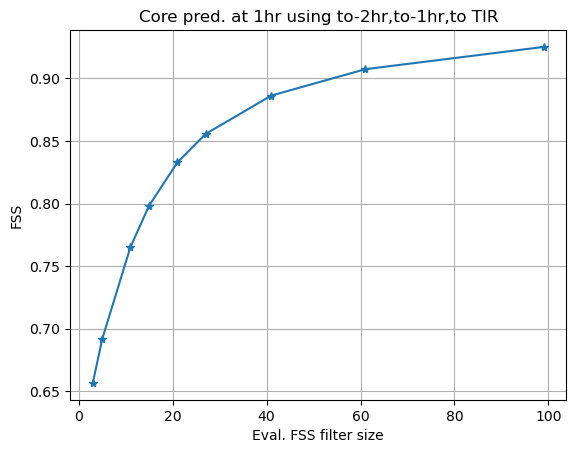

In [19]:
plt.plot(FSS_eval_kernel, ffs_array, linestyle='-',marker="*")
plt.xlabel('Eval. FSS filter size')
plt.ylabel('FSS')
# Show the plot
plt.title('Core pred. at 1hr using to-2hr,to-1hr,to TIR')
plt.grid()
plt.show()

In [ ]:
#with open('../../pkl_files/WA_512_15yr/Eval_FSS_scores_3channel_1hr_using_1hr_TIR_multiyear'+current_year+'.pkl', 'wb') as file: 
 #   pickle.dump([FSS_eval_kernel,ffs_array], file) 


In [104]:
'''
y_test1= tf.expand_dims(y_test, axis=3)
y_test1= tf.cast(y_test1, tf.float32)
#[max_ffs, indx] = np.nax(ffs_array)
core_prob_threshold=0.3
y_pred = np.zeros((x_test.shape[0],image_height,image_width))
ind_okay = np.where(predicted_frames>core_prob_threshold)
y_pred[ind_okay] = 1
y_pred1 = tf.expand_dims(y_pred, axis=3)
y_pred1 = tf.cast(y_pred1, tf.float32)
half_window_size=[1, 2, 5, 7, 9, 12, 17, 25, 37]
ffs_array = []
FSS_eval_kernel=[]

for FFS_kernal_size in half_window_size:
    FSS_Score = FSS_accuracy_metric(y_test1, y_pred1,FFS_kernal_size)
    print(FSS_Score)
    ffs_array.append(FSS_Score) 
    FSS_eval_kernel.append(FFS_kernal_size*2+1)
    '''

tf.Tensor(0.17582959, shape=(), dtype=float32)
tf.Tensor(0.19309503, shape=(), dtype=float32)
tf.Tensor(0.23058838, shape=(), dtype=float32)
tf.Tensor(0.25321782, shape=(), dtype=float32)
tf.Tensor(0.27468067, shape=(), dtype=float32)
tf.Tensor(0.30513185, shape=(), dtype=float32)
tf.Tensor(0.35088032, shape=(), dtype=float32)
tf.Tensor(0.41096026, shape=(), dtype=float32)
tf.Tensor(0.4755873, shape=(), dtype=float32)


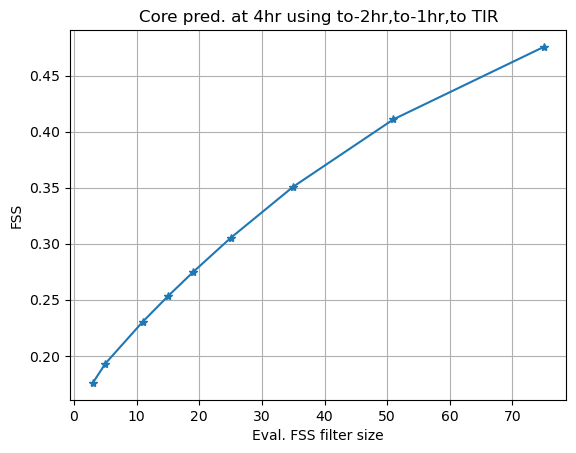

In [105]:
'''
plt.plot(FSS_eval_kernel, ffs_array, linestyle='-',marker="*")
plt.xlabel('Eval. FSS filter size')
plt.ylabel('FSS')
# Show the plot
plt.title('Core pred. at 4hr using to-2hr,to-1hr,to TIR')
plt.grid()
plt.show()
'''